In [1]:
%run 00setup.ipynb

✅ Setup complete


In [2]:
from scipy.optimize import minimize

np.random.seed(42)

In [3]:
MC_SEED = 42
N_BOOT = 2000
N_RANDOM_PORTS = 20000
N_INPUT_MC = 50
BLOCK_SIZE = 20
TRADING_DAYS = 252
ALPHA_CVAR = 0.05
HYBRID_LAMBDA = 0.80
MAX_W = 0.60
USE_LONG_ONLY = True

np.random.seed(MC_SEED)

In [4]:
# -----------------------------
# Helpers
# -----------------------------
def annualized_return(ret: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    wealth = (1 + ret).prod()
    n_years = len(ret) / periods_per_year
    if n_years <= 0:
        return np.nan
    return wealth ** (1 / n_years) - 1

def annualized_vol(ret: pd.Series, periods_per_year: int = TRADING_DAYS) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    return ret.std(ddof=1) * np.sqrt(periods_per_year)

def sharpe_ratio(ret: pd.Series, rf: float = 0.0, periods_per_year: int = TRADING_DAYS) -> float:
    ret = ret.dropna()
    if len(ret) < 2:
        return np.nan
    ann_ret = annualized_return(ret, periods_per_year)
    ann_vol = annualized_vol(ret, periods_per_year)
    if ann_vol == 0 or np.isnan(ann_vol):
        return np.nan
    return (ann_ret - rf) / ann_vol

def max_drawdown(ret: pd.Series) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    return dd.min()

def cvar_from_returns(ret: pd.Series, alpha: float = ALPHA_CVAR) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    q = ret.quantile(alpha)
    tail = ret[ret <= q]
    if len(tail) == 0:
        return q
    return tail.mean()

def perf_summary(ret: pd.Series, name: str = None) -> pd.Series:
    out = pd.Series({
        "CAGR": annualized_return(ret),
        "AnnVol": annualized_vol(ret),
        "Sharpe": sharpe_ratio(ret),
        "MaxDD": max_drawdown(ret),
        "CVaR_5pct": cvar_from_returns(ret, alpha=0.05),
        "TerminalWealth": (1 + ret.dropna()).prod()
    })
    if name is not None:
        out.name = name
    return out

In [5]:
def iid_bootstrap_returns(ret: pd.Series, n_boot: int = N_BOOT) -> pd.DataFrame:
    ret = ret.dropna().values
    T = len(ret)
    sims = np.empty((T, n_boot))
    for i in range(n_boot):
        idx = np.random.randint(0, T, size=T)
        sims[:, i] = ret[idx]
    return pd.DataFrame(sims)

def block_bootstrap_returns(ret: pd.Series, block_size: int = BLOCK_SIZE, n_boot: int = N_BOOT) -> pd.DataFrame:
    ret = ret.dropna().values
    T = len(ret)
    sims = np.empty((T, n_boot))
    n_blocks = int(np.ceil(T / block_size))
    
    for i in range(n_boot):
        sampled = []
        for _ in range(n_blocks):
            start = np.random.randint(0, max(1, T - block_size + 1))
            block = ret[start:start + block_size]
            sampled.extend(block.tolist())
        sims[:, i] = np.array(sampled[:T])
    
    return pd.DataFrame(sims)

def sim_perf_table(sim_df: pd.DataFrame, strategy_name: str, benchmark_ret: pd.Series = None) -> pd.DataFrame:
    rows = []
    for col in sim_df.columns:
        s = pd.Series(sim_df[col])
        row = perf_summary(s, name=col).to_dict()
        if benchmark_ret is not None:
            bench_tw = (1 + benchmark_ret.dropna()).prod()
            row["BeatBenchmark"] = row["TerminalWealth"] > bench_tw
        rows.append(row)
    out = pd.DataFrame(rows)
    out["Strategy"] = strategy_name
    return out

In [6]:
# Random portfolio generation
def random_long_only_weights(n_assets: int, n_ports: int = N_RANDOM_PORTS) -> np.ndarray:
    w = np.random.dirichlet(alpha=np.ones(n_assets), size=n_ports)
    return w

def portfolio_moments(weights: np.ndarray, mu: np.ndarray, cov: np.ndarray):
    port_ret = weights @ mu
    port_vol = np.sqrt(np.einsum("ij,jk,ik->i", weights, cov, weights))
    return port_ret, port_vol

def portfolio_cvar_hist(weights: np.ndarray, ret_matrix: np.ndarray, alpha: float = ALPHA_CVAR) -> np.ndarray:
    # ret_matrix shape: T x N
    port_rets = ret_matrix @ weights.T   # T x M
    cvars = np.empty(port_rets.shape[1])
    for i in range(port_rets.shape[1]):
        r = pd.Series(port_rets[:, i])
        cvars[i] = cvar_from_returns(r, alpha=alpha)
    return cvars

In [7]:
# Optimization helpers

def project_sum_to_one(w):
    w = np.asarray(w)
    s = w.sum()
    if s == 0:
        return np.ones_like(w) / len(w)
    return w / s

def apply_bounds_and_normalize(w, lb=0.0, ub=MAX_W):
    w = np.clip(w, lb, ub)
    return project_sum_to_one(w)

def solve_min_var(cov: np.ndarray, max_w: float = MAX_W) -> np.ndarray:
    n = cov.shape[0]
    x0 = np.ones(n) / n
    bounds = [(0.0, max_w) for _ in range(n)] if USE_LONG_ONLY else [(-1.0, 1.0) for _ in range(n)]
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    
    def obj(w):
        return w @ cov @ w
    
    res = minimize(obj, x0=x0, bounds=bounds, constraints=cons, method="SLSQP")
    if not res.success:
        return x0
    return res.x

def solve_mean_variance(mu: np.ndarray, cov: np.ndarray, risk_aversion: float = 5.0, max_w: float = MAX_W) -> np.ndarray:
    n = len(mu)
    x0 = np.ones(n) / n
    bounds = [(0.0, max_w) for _ in range(n)] if USE_LONG_ONLY else [(-1.0, 1.0) for _ in range(n)]
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    
    def obj(w):
        return -(w @ mu - 0.5 * risk_aversion * (w @ cov @ w))
    
    res = minimize(obj, x0=x0, bounds=bounds, constraints=cons, method="SLSQP")
    if not res.success:
        return x0
    return res.x

def solve_min_cvar_hist(ret_matrix: np.ndarray, alpha: float = ALPHA_CVAR, max_w: float = MAX_W) -> np.ndarray:
    # historical CVaR optimization using Rockafellar-Uryasev style formulation
    # ret_matrix shape: T x N
    T, n = ret_matrix.shape
    x0_w = np.ones(n) / n
    x0 = np.concatenate([x0_w, [0.0], np.zeros(T)])   # w, zeta, u
    
    bounds = [(0.0, max_w) for _ in range(n)] + [(None, None)] + [(0.0, None) for _ in range(T)]
    
    cons = [
        {"type": "eq", "fun": lambda x: np.sum(x[:n]) - 1.0}
    ]
    
    # u_t >= -r_p_t - zeta
    # implemented as u_t + r_p_t + zeta >= 0
    def scenario_constraints(x):
        w = x[:n]
        zeta = x[n]
        u = x[n+1:]
        port_ret = ret_matrix @ w
        return u + port_ret + zeta
    
    cons.append({"type": "ineq", "fun": scenario_constraints})
    
    def obj(x):
        zeta = x[n]
        u = x[n+1:]
        return -(zeta - (1 / (alpha * T)) * np.sum(u))  # maximizing tail mean of returns
    
    res = minimize(obj, x0=x0, bounds=bounds, constraints=cons, method="SLSQP", options={"maxiter": 500})
    
    if not res.success:
        return x0_w
    return res.x[:n]

def hybrid_mv_cvar(mu: np.ndarray, cov: np.ndarray, ret_matrix: np.ndarray,
                   lam: float = HYBRID_LAMBDA, max_w: float = MAX_W) -> np.ndarray:
    w_mv = solve_mean_variance(mu, cov, max_w=max_w)
    w_cvar = solve_min_cvar_hist(ret_matrix, max_w=max_w)
    w = lam * w_mv + (1 - lam) * w_cvar
    return apply_bounds_and_normalize(w, 0.0, max_w)

In [8]:
# -----------------------------
# Load actual backtest outputs
# -----------------------------
prices = load_df("prices_clean", DATA_DIR, fmt="parquet")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

px_col = "adj_close"
prices["ret_1d"] = prices.groupby("ticker")[px_col].pct_change()

R = prices.pivot(index="date", columns="ticker", values="ret_1d").sort_index()
R = R.replace([np.inf, -np.inf], np.nan).dropna(how="all")

res_eq   = load_df("bt_eq_topk", DATA_DIR, fmt="parquet")
res_vp   = load_df("bt_invvol_topk", DATA_DIR, fmt="parquet")
res_mv   = load_df("bt_mv_topk", DATA_DIR, fmt="parquet")
res_cvar = load_df("bt_cvar_topk", DATA_DIR, fmt="parquet")
res_hyb  = load_df("bt_hybrid_topk", DATA_DIR, fmt="parquet")

for df in [res_eq, res_vp, res_mv, res_cvar, res_hyb]:
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)

# rebuild benchmark exactly as in your backtest
bench_eq_univ = R.mean(axis=1).fillna(0.0)

def vol_target(net_ret, target_vol=0.12, lookback=63):
    vol = net_ret.rolling(lookback).std() * np.sqrt(252)
    scale = (target_vol / vol).replace([np.inf, -np.inf], np.nan).clip(0, 3.0)
    scale = scale.shift(1).fillna(0.0)
    return net_ret * scale, scale

bench_eq_univ_vt, bench_eq_univ_scale = vol_target(bench_eq_univ, target_vol=0.12, lookback=63)

In [9]:
# -----------------------------
# Build strategy return table from your actual saved outputs
# -----------------------------
strat_ret = pd.DataFrame({
    "EQ": res_eq["vt"],
    "INVVOL": res_vp["vt"],
    "MV": res_mv["vt"],
    "CVaR": res_cvar["vt"],
    "HYBRID": res_hyb["vt"],
    "BENCHMARK": bench_eq_univ_vt
}).sort_index()

asset_ret_wide = R.copy()

print("Strategy return columns:")
print(strat_ret.columns.tolist())
display(strat_ret.head())

print("Asset return matrix shape:", asset_ret_wide.shape)
display(asset_ret_wide.head())

Strategy return columns:
['EQ', 'INVVOL', 'MV', 'CVaR', 'HYBRID', 'BENCHMARK']


,EQ,INVVOL,MV,CVaR,HYBRID,BENCHMARK
date,,,,,,
2011-10-21,0.0,0.0,0.0,0.0,0.0,0.0
2011-10-24,0.0,0.0,0.0,0.0,0.0,0.0
2011-10-25,0.0,0.0,0.0,0.0,0.0,-0.0
2011-10-26,0.0,0.0,0.0,0.0,0.0,0.0
2011-10-27,0.0,0.0,0.0,0.0,0.0,0.0


Asset return matrix shape: (3568, 20)


ticker,DBC,DIA,EEM,EWJ,EWU,FEZ,GLD,IEF,IWM,LQD,QQQ,SHY,SPY,TLT,USMV,VNQ,VTV,VUG,XLP,XLU
date,,,,,,,,,,,,,,,,,,,,
2011-10-21,0.005177,0.023492,0.028586,0.010537,0.023500,0.031654,0.011092,-0.001847,0.021688,0.003286,0.012546,-0.000355,0.018987,-0.010582,0.012224,0.032958,0.018269,0.020232,0.016145,0.016910
2011-10-24,0.015820,0.008739,0.039115,0.010427,0.013897,0.014715,0.009403,-0.000487,0.032195,0.005134,0.020768,0.000000,0.012261,0.001679,NaN,0.024837,0.012285,0.016580,-0.006990,-0.004300
2011-10-25,0.003260,-0.017581,-0.019812,-0.014448,-0.012515,-0.019747,0.028382,0.008573,-0.028058,0.004933,-0.019662,0.000591,-0.019444,0.025415,-0.003506,-0.016274,-0.020227,-0.019827,-0.011840,-0.011229
2011-10-26,-0.005776,0.013871,0.018444,0.002094,0.016295,0.012590,0.010931,-0.007341,0.017236,-0.000702,-0.001221,-0.000591,0.010159,-0.017470,0.004300,0.007373,0.014156,0.006688,0.010039,0.004076
2011-10-27,0.026507,0.029812,0.060779,0.038662,0.039193,0.085483,0.012844,-0.012066,0.052762,-0.000175,0.027588,-0.000710,0.034835,-0.033897,0.013234,0.047483,0.035091,0.031923,0.012825,0.023782


In [10]:
STRATEGY_COLS = ["EQ", "INVVOL", "MV", "CVaR", "HYBRID"]
BENCH_COL = "BENCHMARK"
live_mask = strat_ret[STRATEGY_COLS].abs().sum(axis=1) > 1e-12
common_start = strat_ret.index[live_mask][0]
print("Strategy cols:", STRATEGY_COLS)
print("Benchmark col:", BENCH_COL)

Strategy cols: ['EQ', 'INVVOL', 'MV', 'CVaR', 'HYBRID']
Benchmark col: BENCHMARK


In [11]:
# Basic summary of realized OOS performance

if strat_ret is not None:
    base_summary = pd.concat(
        [perf_summary(strat_ret[c], name=c) for c in STRATEGY_COLS + ([BENCH_COL] if BENCH_COL else [])],
        axis=1
    ).T
    display(base_summary.round(4))
    
    save_df(base_summary.reset_index().rename(columns={"index": "strategy"}), "base summary", DATA_DIR ,fmt="parquet")

,CAGR,AnnVol,Sharpe,MaxDD,CVaR_5pct,TerminalWealth
EQ,0.0607,0.1097,0.5530,-0.2188,-0.0174,2.3026
INVVOL,0.0668,0.1097,0.6091,-0.2160,-0.0174,2.4996
MV,0.0495,0.1096,0.4520,-0.2206,-0.0174,1.9830
CVaR,0.0498,0.1098,0.4535,-0.2490,-0.0173,1.9898
HYBRID,0.0502,0.1097,0.4579,-0.2246,-0.0174,2.0016
BENCHMARK,0.0989,0.1275,0.7755,-0.2267,-0.0196,3.8010


In [12]:
# -----------------------------
# 1) Bootstrap robustness
# -----------------------------
boot_results = []

if strat_ret is not None:
    benchmark_ret = strat_ret[BENCH_COL] if BENCH_COL else None
    
    for c in STRATEGY_COLS:
        s = strat_ret[c].dropna()
        
        iid_sims = iid_bootstrap_returns(s, n_boot=N_BOOT)
        iid_perf = sim_perf_table(iid_sims, strategy_name=f"{c}_iid", benchmark_ret=benchmark_ret)
        iid_perf["BootstrapType"] = "iid"
        iid_perf["BaseStrategy"] = c
        
        block_sims = block_bootstrap_returns(s, block_size=BLOCK_SIZE, n_boot=N_BOOT)
        block_perf = sim_perf_table(block_sims, strategy_name=f"{c}_block", benchmark_ret=benchmark_ret)
        block_perf["BootstrapType"] = "block"
        block_perf["BaseStrategy"] = c
        
        boot_results.append(iid_perf)
        boot_results.append(block_perf)

boot_results_df = pd.concat(boot_results, axis=0, ignore_index=True) if len(boot_results) > 0 else pd.DataFrame()
display(boot_results_df.head())

,CAGR,AnnVol,Sharpe,MaxDD,CVaR_5pct,TerminalWealth,BeatBenchmark,Strategy,BootstrapType,BaseStrategy
0,0.083277,0.105479,0.789513,-0.215449,-0.016343,3.103616,False,EQ_iid,iid,EQ
1,0.016345,0.103826,0.157430,-0.281698,-0.017352,1.258045,False,EQ_iid,iid,EQ
2,0.038140,0.108102,0.352819,-0.341823,-0.017975,1.698889,False,EQ_iid,iid,EQ
3,0.090090,0.101065,0.891407,-0.287605,-0.015509,3.391705,False,EQ_iid,iid,EQ
4,0.071186,0.108082,0.658632,-0.232786,-0.016679,2.647585,False,EQ_iid,iid,EQ


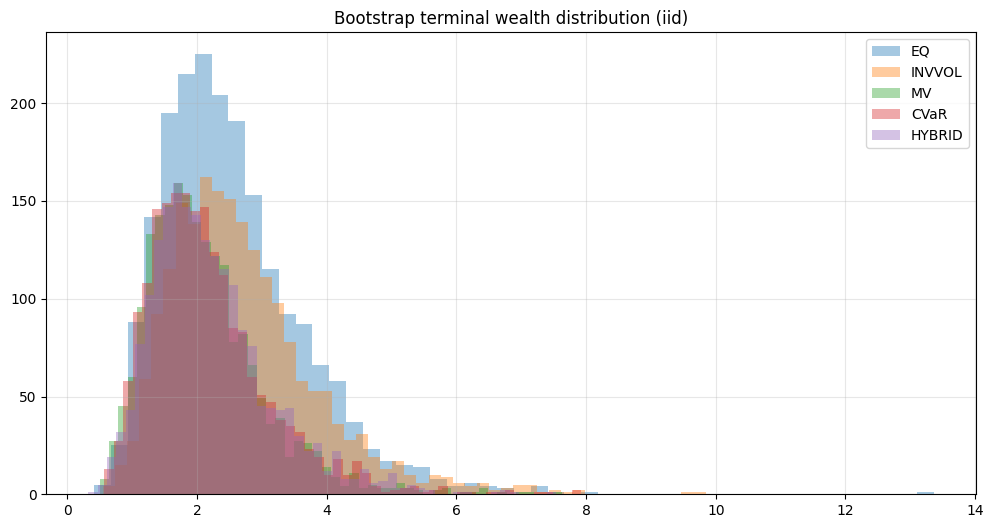

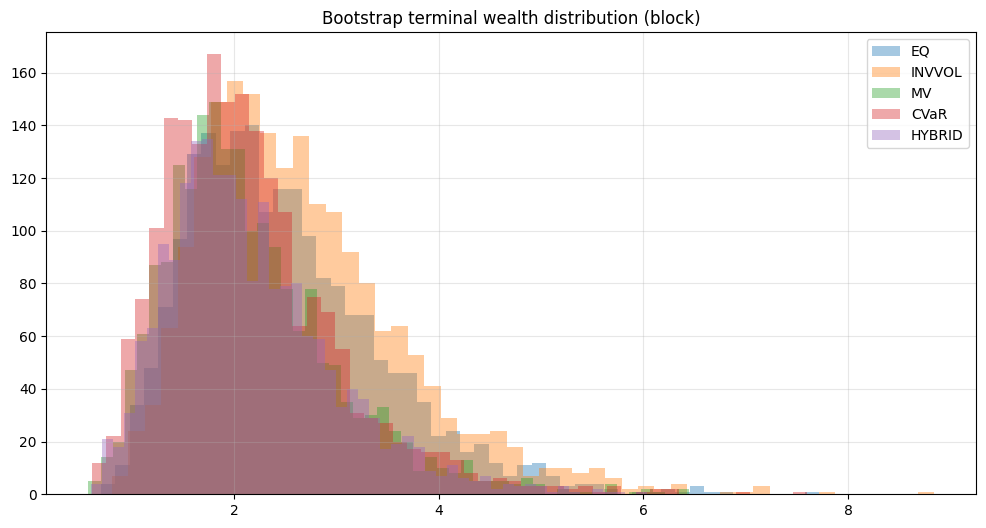

In [13]:
# Plot bootstrap terminal wealth distributions

if not boot_results_df.empty:
    for btype in ["iid", "block"]:
        sub = boot_results_df[boot_results_df["BootstrapType"] == btype]
        plt.figure(figsize=(12, 6))
        for strat in sub["BaseStrategy"].unique():
            vals = sub.loc[sub["BaseStrategy"] == strat, "TerminalWealth"].dropna()
            plt.hist(vals, bins=50, alpha=0.4, label=strat)
        plt.title(f"Bootstrap terminal wealth distribution ({btype})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [14]:
# Compact robustness table for presentation/report

if not boot_results_df.empty:
    robust_table = (
        boot_results_df
        .groupby(["BaseStrategy", "BootstrapType"])
        .agg(
            CAGR_p5=("CAGR", lambda x: x.quantile(0.05)),
            CAGR_med=("CAGR", "median"),
            CAGR_p95=("CAGR", lambda x: x.quantile(0.95)),
            Sharpe_p5=("Sharpe", lambda x: x.quantile(0.05)),
            Sharpe_med=("Sharpe", "median"),
            Sharpe_p95=("Sharpe", lambda x: x.quantile(0.95)),
            MaxDD_med=("MaxDD", "median"),
            TW_p5=("TerminalWealth", lambda x: x.quantile(0.05)),
            TW_med=("TerminalWealth", "median"),
            TW_p95=("TerminalWealth", lambda x: x.quantile(0.95)),
        )
        .reset_index()
    )
    if "BeatBenchmark" in boot_results_df.columns:
        beat = (
            boot_results_df
            .groupby(["BaseStrategy", "BootstrapType"])["BeatBenchmark"]
            .mean()
            .reset_index(name="ProbBeatBenchmark")
        )
        robust_table = robust_table.merge(beat, on=["BaseStrategy", "BootstrapType"], how="left")
    
    display(robust_table.round(4))
    save_df(robust_table,"bootstrap_summary", DATA_DIR, fmt="parquet" )

,BaseStrategy,BootstrapType,CAGR_p5,CAGR_med,CAGR_p95,Sharpe_p5,Sharpe_med,Sharpe_p95,MaxDD_med,TW_p5,TW_med,TW_p95,ProbBeatBenchmark
0,CVaR,block,0.0037,0.0506,0.0985,0.0349,0.4625,0.9174,-0.2355,1.0543,2.0109,3.7798,0.0490
1,CVaR,iid,0.0010,0.0500,0.1011,0.0089,0.4546,0.9501,-0.2525,1.0145,1.9941,3.9109,0.0580
2,EQ,block,0.0169,0.0615,0.1083,0.1541,0.5616,1.0053,-0.2184,1.2686,2.3289,4.2892,0.0925
3,EQ,iid,0.0105,0.0626,0.1134,0.0931,0.5661,1.0554,-0.2391,1.1601,2.3625,4.5782,0.1280
4,HYBRID,block,0.0058,0.0506,0.0962,0.0507,0.4637,0.9046,-0.2330,1.0848,2.0123,3.6703,0.0405
5,HYBRID,iid,0.0032,0.0520,0.1026,0.0296,0.4768,0.9594,-0.2534,1.0459,2.0498,3.9884,0.0645
6,INVVOL,block,0.0229,0.0658,0.1136,0.2101,0.6045,1.0676,-0.2157,1.3785,2.4653,4.5898,0.1215
7,INVVOL,iid,0.0175,0.0669,0.1183,0.1602,0.6111,1.0964,-0.2336,1.2792,2.5004,4.8685,0.1475
8,MV,block,0.0054,0.0503,0.0969,0.0485,0.4578,0.9203,-0.2318,1.0788,2.0028,3.7025,0.0480
9,MV,iid,0.0003,0.0487,0.0983,0.0028,0.4438,0.9068,-0.2560,1.0042,1.9602,3.7706,0.0485


In [15]:
common_idx = strat_ret.dropna().index
asset_ret_wide = asset_ret_wide.reindex(common_idx).dropna(how="any")
strat_ret = strat_ret.reindex(common_idx).dropna(how="any")

In [16]:
# -----------------------------
# 2) Random portfolio cloud
# -----------------------------
if asset_ret_wide is not None:
    # use realized full-sample OOS asset returns as the cloud input
    rp_ret = asset_ret_wide.dropna(how="any").copy()
    mu_hat = rp_ret.mean().values * TRADING_DAYS
    cov_hat = rp_ret.cov().values * TRADING_DAYS
    assets = rp_ret.columns.tolist()
    
    rand_w = random_long_only_weights(len(assets), n_ports=N_RANDOM_PORTS)
    rand_ret, rand_vol = portfolio_moments(rand_w, mu_hat, cov_hat)
    rand_cvar = portfolio_cvar_hist(rand_w, rp_ret.values, alpha=ALPHA_CVAR)
    
    random_cloud = pd.DataFrame({
        "AnnReturn": rand_ret,
        "AnnVol": rand_vol,
        "Sharpe": np.where(rand_vol > 0, rand_ret / rand_vol, np.nan),
        "CVaR_5pct": rand_cvar
    })
    
    display(random_cloud.head())
    save_df(random_cloud, "random_portfolio_cloud",DATA_DIR, fmt="parquet" )

,AnnReturn,AnnVol,Sharpe,CVaR_5pct
0,0.089868,0.119775,0.750310,-0.017509
1,0.064954,0.074640,0.870237,-0.010877
2,0.099817,0.118972,0.839003,-0.017558
3,0.077497,0.106158,0.730016,-0.015795
4,0.091057,0.107554,0.846611,-0.015660


In [30]:
# Solve canonical portfolios on the same input set
canonical_weights = {}

if asset_ret_wide is not None:
    eps = 1e-4
    cov_hat_stable = cov_hat + eps * np.eye(cov_hat.shape[0])

    w_eq = np.ones(len(assets)) / len(assets)

    w_iv = 1 / np.sqrt(np.diag(cov_hat_stable))
    w_iv = w_iv / w_iv.sum()
    w_iv = apply_bounds_and_normalize(w_iv, 0.0, MAX_W)

    canonical_weights["EQ"] = w_eq
    canonical_weights["INVVOL"] = w_iv

    cw_df = pd.DataFrame(canonical_weights, index=assets)
    display(cw_df.round(4))

,EQ,INVVOL
DBC,0.05,0.0323
DIA,0.05,0.0330
EEM,0.05,0.0266
EWJ,0.05,0.0309
EWU,0.05,0.0294
FEZ,0.05,0.0250
GLD,0.05,0.0347
IEF,0.05,0.0827
IWM,0.05,0.0251
LQD,0.05,0.0684


In [18]:
rows = []
for name, w in canonical_weights.items():
    pr = rp_ret.values @ w
    rows.append({
        "Portfolio": name,
        "AnnReturn": annualized_return(pd.Series(pr)),
        "AnnVol": annualized_vol(pd.Series(pr)),
        "Sharpe": sharpe_ratio(pd.Series(pr)),
        "CVaR_5pct": cvar_from_returns(pd.Series(pr), alpha=ALPHA_CVAR),
        "MaxDD": max_drawdown(pd.Series(pr))
    })
canonical_stats = pd.DataFrame(rows)
display(canonical_stats.round(4))

,Portfolio,AnnReturn,AnnVol,Sharpe,CVaR_5pct,MaxDD
0,EQ,0.0895,0.1127,0.7935,-0.0165,-0.2532
1,INVVOL,0.0620,0.0698,0.8881,-0.0101,-0.1545


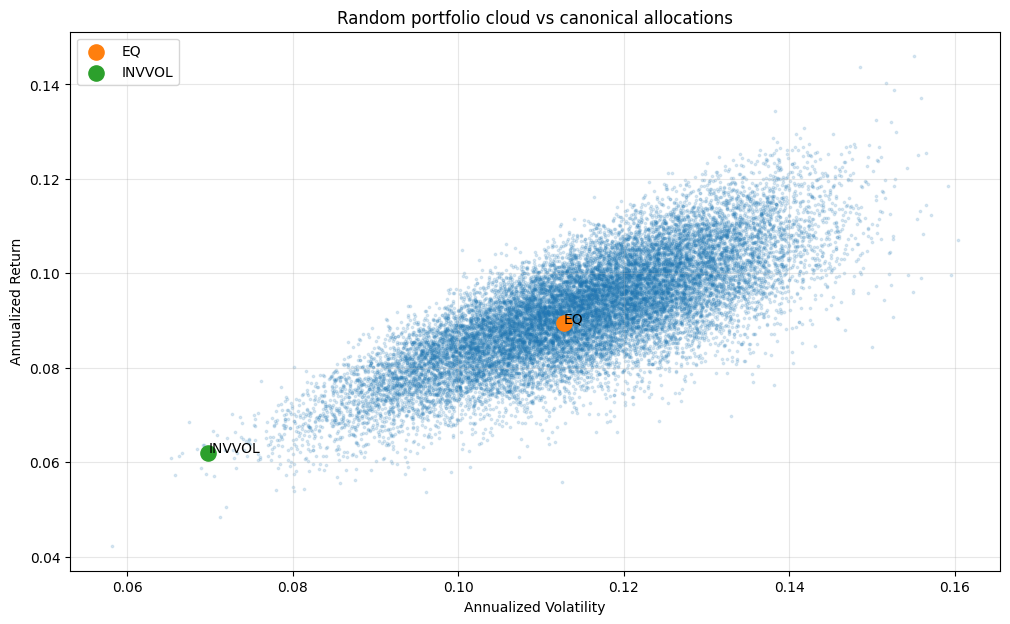

In [19]:
# Plot return-volatility cloud with canonical portfolios

if asset_ret_wide is not None:
    plt.figure(figsize=(12, 7))
    plt.scatter(random_cloud["AnnVol"], random_cloud["AnnReturn"], s=3, alpha=0.15)
    
    for _, row in canonical_stats.iterrows():
        plt.scatter(row["AnnVol"], row["AnnReturn"], s=120, label=row["Portfolio"])
        plt.text(row["AnnVol"], row["AnnReturn"], row["Portfolio"])
    
    plt.xlabel("Annualized Volatility")
    plt.ylabel("Annualized Return")
    plt.title("Random portfolio cloud vs canonical allocations")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

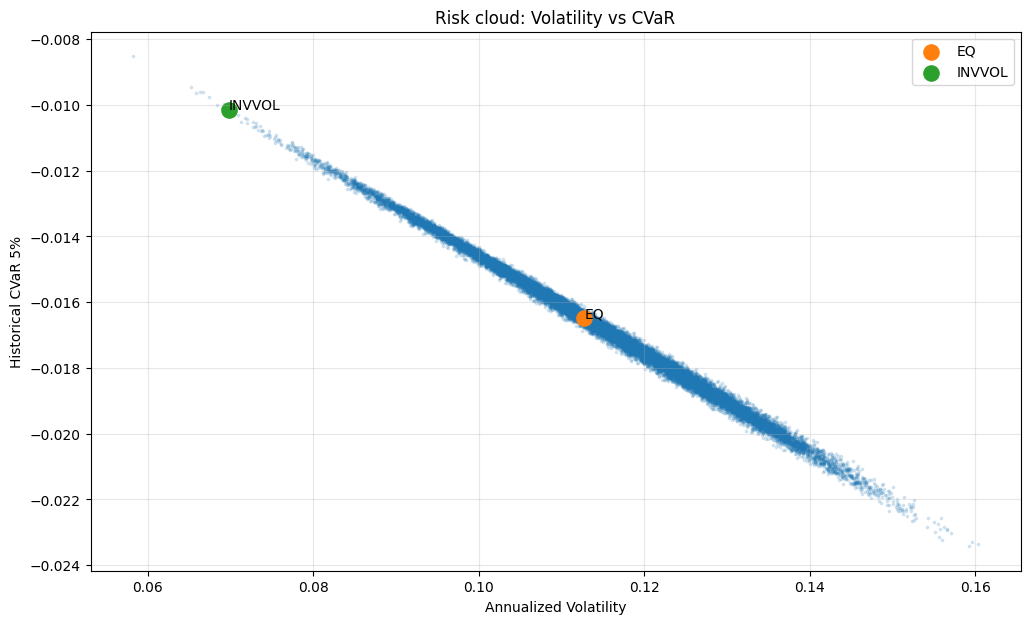

In [20]:
# Plot volatility vs CVaR cloud

if asset_ret_wide is not None:
    plt.figure(figsize=(12, 7))
    plt.scatter(random_cloud["AnnVol"], random_cloud["CVaR_5pct"], s=3, alpha=0.15)
    
    for name, w in canonical_weights.items():
        pr = pd.Series(rp_ret.values @ w)
        x = annualized_vol(pr)
        y = cvar_from_returns(pr, alpha=ALPHA_CVAR)
        plt.scatter(x, y, s=120, label=name)
        plt.text(x, y, name)
    
    plt.xlabel("Annualized Volatility")
    plt.ylabel("Historical CVaR 5%")
    plt.title("Risk cloud: Volatility vs CVaR")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [21]:
# -----------------------------
# 3) Input-uncertainty Monte Carlo
# -----------------------------
# Idea:
# perturb estimated means/covariances through resampling
# re-solve MV / CVaR / HYBRID
# study stability, concentration, and turnover

input_mc_rows = []
weight_store = []

if asset_ret_wide is not None:
    base_ret = rp_ret.copy()
    T, N = base_ret.shape

    for i in range(N_INPUT_MC):
        # block bootstrap row indices
        idx_blocks = []
        n_blocks = int(np.ceil(T / BLOCK_SIZE))
        for _ in range(n_blocks):
            start = np.random.randint(0, max(1, T - BLOCK_SIZE + 1))
            idx_blocks.extend(range(start, min(start + BLOCK_SIZE, T)))
        idx = idx_blocks[:T]

        sim_ret = base_ret.iloc[idx].reset_index(drop=True)

        # estimate moments from resampled data
        mu_sim = sim_ret.mean().values * TRADING_DAYS
        cov_sim = sim_ret.cov().values * TRADING_DAYS

        # perturb means slightly to reflect estimation noise
        mu_noise = np.random.normal(
            0, np.maximum(np.abs(mu_sim), 1e-6) * 0.10, size=N
        )
        mu_pert = mu_sim + mu_noise

        # stabilize covariance
        cov_jitter = np.diag(np.random.uniform(1e-6, 1e-4, size=N))
        cov_pert = cov_sim + cov_jitter

        # portfolios
        w_eq = np.ones(N) / N

        invvol = 1 / np.sqrt(np.clip(np.diag(cov_pert), 1e-12, None))
        w_iv = invvol / invvol.sum()
        w_iv = apply_bounds_and_normalize(w_iv, 0.0, MAX_W)

        w_mv = solve_mean_variance(mu_pert, cov_pert, max_w=MAX_W)

        for name, w in {"EQ": w_eq, "INVVOL": w_iv, "MV": w_mv}.items():
            pr = pd.Series(base_ret.values @ w)

            input_mc_rows.append({
                "Sim": i,
                "Portfolio": name,
                "AnnReturn": annualized_return(pr),
                "AnnVol": annualized_vol(pr),
                "Sharpe": sharpe_ratio(pr),
                "CVaR_5pct": cvar_from_returns(pr, alpha=ALPHA_CVAR),
                "MaxDD": max_drawdown(pr),
                "MaxWeight": np.max(w),
                "HHI": np.sum(w**2),
                "NumWeightsOver20": np.sum(w > 0.20)
            })

            for a, ww in zip(assets, w):
                weight_store.append({
                    "Sim": i,
                    "Portfolio": name,
                    "Asset": a,
                    "Weight": ww
                })

input_mc_df = pd.DataFrame(input_mc_rows)
weight_store_df = pd.DataFrame(weight_store)

display(input_mc_df.head())
display(weight_store_df.head())

save_df(input_mc_df, "input_uncertainty_mc_stats", DATA_DIR, fmt="parquet")
save_df(weight_store_df, "input_uncertainty_mc_weights", DATA_DIR, fmt="parquet")

,Sim,Portfolio,AnnReturn,AnnVol,Sharpe,CVaR_5pct,MaxDD,MaxWeight,HHI,NumWeightsOver20
0,0,EQ,0.089457,0.112745,0.793450,-0.016464,-0.253237,0.050000,0.050000,0
1,0,INVVOL,0.061228,0.068493,0.893922,-0.009953,-0.151671,0.338528,0.141026,1
2,0,MV,0.142070,0.140365,1.012147,-0.020553,-0.259344,0.548651,0.434907,2
3,1,EQ,0.089457,0.112745,0.793450,-0.016464,-0.253237,0.050000,0.050000,0
4,1,INVVOL,0.062014,0.070013,0.885758,-0.010180,-0.155007,0.323785,0.132271,1


,Sim,Portfolio,Asset,Weight
0,0,EQ,DBC,0.05
1,0,EQ,DIA,0.05
2,0,EQ,EEM,0.05
3,0,EQ,EWJ,0.05
4,0,EQ,EWU,0.05


In [23]:
# Summary of input-uncertainty Monte Carlo

if not input_mc_df.empty:
    input_mc_summary = (
        input_mc_df
        .groupby("Portfolio")
        .agg(
            Return_mean=("AnnReturn", "mean"),
            Return_p5=("AnnReturn", lambda x: x.quantile(0.05)),
            Return_p95=("AnnReturn", lambda x: x.quantile(0.95)),
            Sharpe_mean=("Sharpe", "mean"),
            Sharpe_p5=("Sharpe", lambda x: x.quantile(0.05)),
            Sharpe_p95=("Sharpe", lambda x: x.quantile(0.95)),
            MaxWeight_mean=("MaxWeight", "mean"),
            HHI_mean=("HHI", "mean"),
            NumWeightsOver20_mean=("NumWeightsOver20", "mean"),
        )
        .reset_index()
    )
    display(input_mc_summary.round(4))
    save_df(input_mc_summary, "input_uncertainty_mc_summary",DATA_DIR ,fmt="parquet" )

,Portfolio,Return_mean,Return_p5,Return_p95,Sharpe_mean,Sharpe_p5,Sharpe_p95,MaxWeight_mean,HHI_mean,NumWeightsOver20_mean
0,EQ,0.0895,0.0895,0.0895,0.7935,0.7935,0.7935,0.0500,0.0500,0.00
1,INVVOL,0.0605,0.0582,0.0628,0.8930,0.8858,0.9027,0.3390,0.1421,1.00
2,MV,0.1351,0.1007,0.1667,0.9496,0.7852,1.0504,0.5462,0.4282,2.08


In [25]:
# Weight stability by asset

if not weight_store_df.empty:
    weight_stability = (
        weight_store_df
        .groupby(["Portfolio", "Asset"])
        .agg(
            MeanWeight=("Weight", "mean"),
            StdWeight=("Weight", "std"),
            MedWeight=("Weight", "median"),
            P95Weight=("Weight", lambda x: x.quantile(0.95))
        )
        .reset_index()
    )
    display(weight_stability.head(20))
    save_df(weight_stability,"weight_stability_by_asset",DATA_DIR ,fmt="parquet" )

,Portfolio,Asset,MeanWeight,StdWeight,MedWeight,P95Weight
0,EQ,DBC,0.05,0.0,0.05,0.05
1,EQ,DIA,0.05,0.0,0.05,0.05
2,EQ,EEM,0.05,0.0,0.05,0.05
3,EQ,EWJ,0.05,0.0,0.05,0.05
4,EQ,EWU,0.05,0.0,0.05,0.05
5,EQ,FEZ,0.05,0.0,0.05,0.05
6,EQ,GLD,0.05,0.0,0.05,0.05
7,EQ,IEF,0.05,0.0,0.05,0.05
8,EQ,IWM,0.05,0.0,0.05,0.05
9,EQ,LQD,0.05,0.0,0.05,0.05


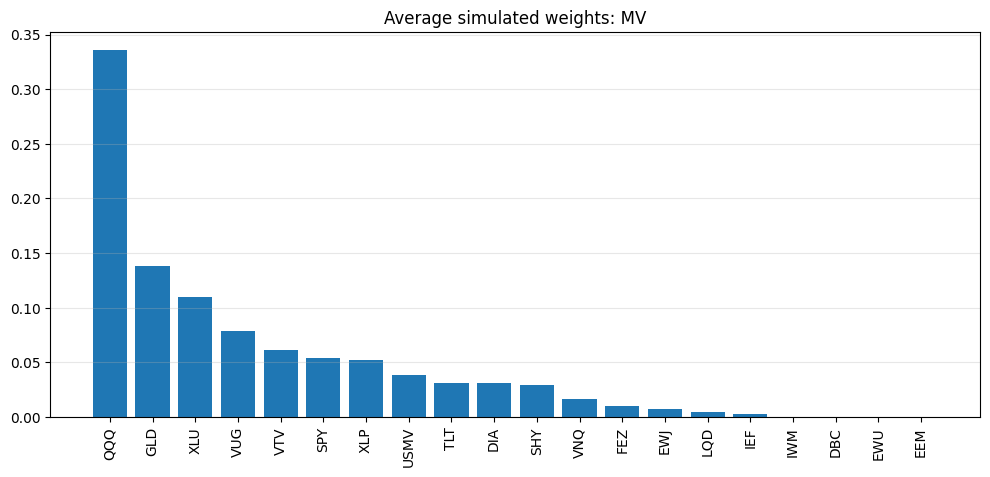

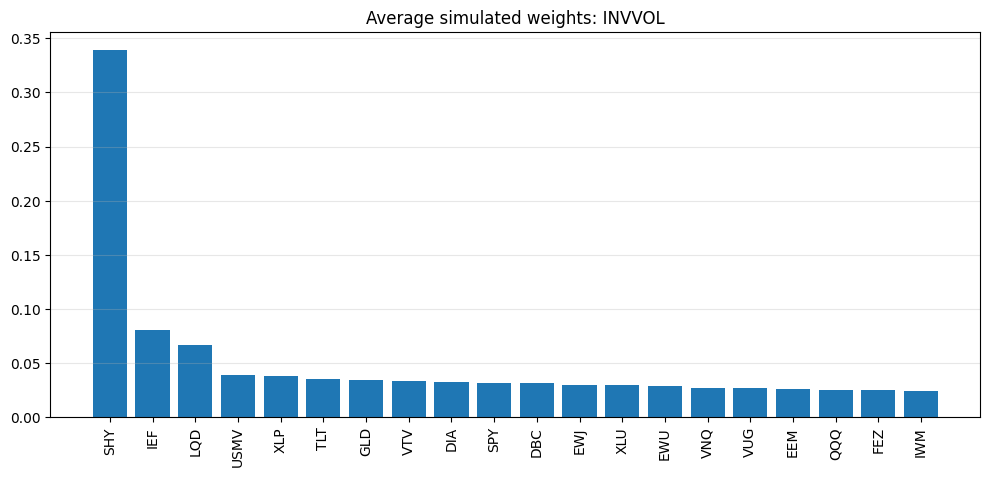

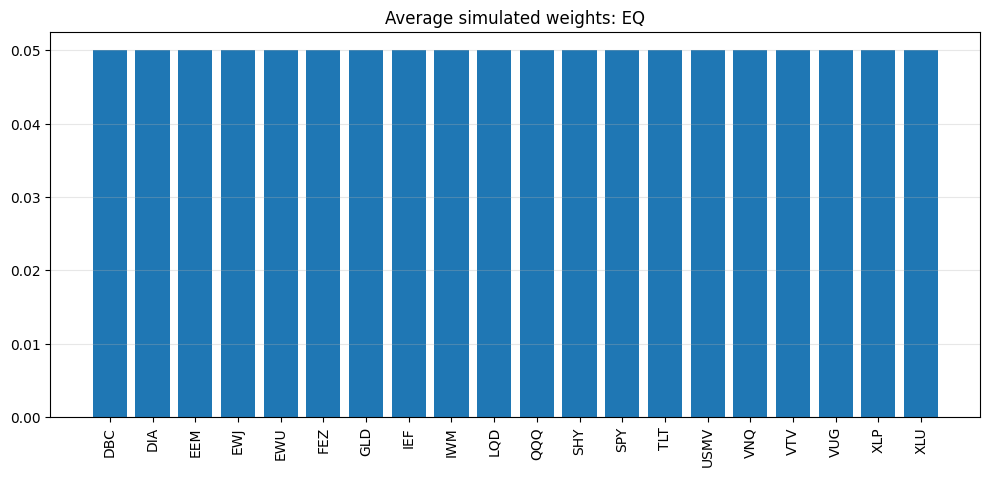

In [28]:
# Plot mean weights across simulations

if not weight_store_df.empty:
    for p in ["MV", "INVVOL", "EQ"]:
        sub = weight_stability[weight_stability["Portfolio"] == p].sort_values("MeanWeight", ascending=False)
        plt.figure(figsize=(12, 5))
        plt.bar(sub["Asset"], sub["MeanWeight"])
        plt.xticks(rotation=90)
        plt.title(f"Average simulated weights: {p}")
        plt.grid(True, axis="y", alpha=0.3)
        plt.show()

In [31]:
weight_stability["Portfolio"].value_counts()
display(
    weight_stability[weight_stability["Portfolio"] == "MV"]
    .sort_values("StdWeight", ascending=False)
    .head(10)
)

,Portfolio,Asset,MeanWeight,StdWeight,MedWeight,P95Weight
50,MV,QQQ,0.335627,0.266354,4.085275e-01,0.600000
59,MV,XLU,0.110161,0.183549,7.551223e-17,0.549751
57,MV,VUG,0.078542,0.172769,7.660898e-17,0.519549
46,MV,GLD,0.137788,0.162420,5.949607e-02,0.387504
56,MV,VTV,0.061211,0.154631,1.293526e-17,0.409926
58,MV,XLP,0.051919,0.138310,1.097771e-17,0.391256
52,MV,SPY,0.053678,0.132512,5.991013e-18,0.351308
54,MV,USMV,0.038632,0.132322,1.676150e-17,0.320444
51,MV,SHY,0.029371,0.095863,1.076989e-17,0.222998
41,MV,DIA,0.030609,0.085134,7.739384e-18,0.218220
